In [1]:
!pip install -q -r requirements.txt


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\ianmu\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import wandb
import os
from dotenv import load_dotenv

load_dotenv()

api_key = os.getenv("WANDB_API_KEY")

if api_key:
    os.environ["WANDB_API_KEY"] = api_key
    wandb.login(key=api_key)
else:
    print("WANDB_API_KEY no está")


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\ianmu\_netrc
wandb: Currently logged in as: mauu (mauu-tec) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [3]:
import torch

# Configurar precisión para Tensor Cores (API nueva)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
print(f"TF32 para matmul: {torch.backends.cuda.matmul.allow_tf32}")
print(f"TF32 para cuDNN: {torch.backends.cudnn.allow_tf32}")

GPU: NVIDIA GeForce RTX 3070 Ti
CUDA disponible: True
TF32 para matmul: True
TF32 para cuDNN: True


C:\Users\ianmu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torch\backends\__init__.py:46: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:85.)
  self.setter(val)


# Entrenamientos

In [12]:
!python src/train_model_a.py model=cnn_scratch logger.wandb.name=A_run1 train.lr=1e-3 trainer.max_epochs=30
!python src/train_model_a.py model=cnn_scratch logger.wandb.name=A_run2 train.lr=5e-4 trainer.max_epochs=50
!python src/train_model_a.py model=cnn_scratch logger.wandb.name=A_run3 train.lr=1e-4 trainer.max_epochs=75

!python src/train_model_b.py model=distilled logger.wandb.name=B_run1 train.lr=1e-4 model.distillation.temperature=4 model.distillation.alpha=0.7 trainer.max_epochs=30
!python src/train_model_b.py model=distilled logger.wandb.name=B_run2 train.lr=5e-5 model.distillation.temperature=3 model.distillation.alpha=0.6 trainer.max_epochs=50
!python src/train_model_b.py model=distilled logger.wandb.name=B_run3 train.lr=1e-5 model.distillation.temperature=5 model.distillation.alpha=0.8 trainer.max_epochs=75

!python src/train_model_c.py model=unet_ae logger.wandb.name=C_run1 train.lr=1e-4 model.latent.dim=128 model.reconstruction.loss=l2 trainer.max_epochs=30
!python src/train_model_c.py model=unet_ae logger.wandb.name=C_run2 train.lr=5e-5 model.latent.dim=256 model.reconstruction.loss=l1 trainer.max_epochs=50
!python src/train_model_c.py model=unet_ae logger.wandb.name=C_run3 train.lr=1e-4 model.latent.dim=64 model.reconstruction.loss=l2 trainer.max_epochs=75



Sanity Checking: |          | 0/? [00:00<?, ?it/s]
Sanity Checking: |          | 0/? [00:00<?, ?it/s]
Sanity Checking DataLoader 0: 100%|██████████| 2/2 [00:00<00:00,  3.01it/s]
                                                                           

Training: |          | 0/? [00:00<?, ?it/s]
Training: |          | 0/? [00:00<?, ?it/s]
Epoch 0: 100%|██████████| 64/64 [00:12<00:00,  4.97it/s, v_num=egc3]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation DataLoader 0:   0%|          | 0/7 [00:00<?, ?it/s]

Validation DataLoader 0:  14%|█▍        | 1/7 [00:00<00:00, 197.19it/s]

Validation DataLoader 0:  29%|██▊       | 2/7 [00:00<00:00, 188.89it/s]

Validation DataLoader 0:  43%|████▎     | 3/7 [00:00<00:00, 211.76it/s]

Validation DataLoader 0:  57%|█████▋    | 4/7 [00:00<00:00, 219.45it/s]

Validation DataLoader 0:  71%|███████▏  | 5/7 [00:00<00:00, 11.86it/s] 

Validation DataLoader 0:  86%|████████▌ | 6/7 [00:00<00:00, 11.

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
C:\Users\ianmu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torch\__init__.py:1551: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:85.)
  return _C._get_float32_matmul_precision()
You are using a CUDA device ('NVIDIA GeForce RTX 3070 Ti') that has Tensor Cores. To properly 


Sanity Checking: |          | 0/? [00:00<?, ?it/s]
Sanity Checking: |          | 0/? [00:00<?, ?it/s]
Sanity Checking DataLoader 0: 100%|██████████| 2/2 [00:00<00:00,  4.60it/s]
                                                                           

Training: |          | 0/? [00:00<?, ?it/s]
Training: |          | 0/? [00:00<?, ?it/s]
Epoch 0: 100%|██████████| 64/64 [00:10<00:00,  5.90it/s, v_num=r40i]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation DataLoader 0:   0%|          | 0/7 [00:00<?, ?it/s]

Validation DataLoader 0:  14%|█▍        | 1/7 [00:00<00:00, 253.20it/s]

Validation DataLoader 0:  29%|██▊       | 2/7 [00:00<00:00, 273.22it/s]

Validation DataLoader 0:  43%|████▎     | 3/7 [00:00<00:00, 254.87it/s]

Validation DataLoader 0:  57%|█████▋    | 4/7 [00:00<00:00, 254.34it/s]

Validation DataLoader 0:  71%|███████▏  | 5/7 [00:00<00:00, 11.84it/s] 

Validation DataLoader 0:  86%|████████▌ | 6/7 [00:00<00:00, 13.

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
C:\Users\ianmu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torch\__init__.py:1551: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:85.)
  return _C._get_float32_matmul_precision()
You are using a CUDA device ('NVIDIA GeForce RTX 3070 Ti') that has Tensor Cores. To properly 


Sanity Checking: |          | 0/? [00:00<?, ?it/s]
Sanity Checking: |          | 0/? [00:00<?, ?it/s]
Sanity Checking DataLoader 0: 100%|██████████| 2/2 [00:00<00:00,  2.58it/s]
                                                                           

Training: |          | 0/? [00:00<?, ?it/s]
Training: |          | 0/? [00:00<?, ?it/s]
Epoch 0: 100%|██████████| 64/64 [00:12<00:00,  5.02it/s, v_num=3g5t]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation DataLoader 0:   0%|          | 0/7 [00:00<?, ?it/s]

Validation DataLoader 0:  14%|█▍        | 1/7 [00:00<00:00, 264.57it/s]

Validation DataLoader 0:  29%|██▊       | 2/7 [00:00<00:00, 238.12it/s]

Validation DataLoader 0:  43%|████▎     | 3/7 [00:00<00:00, 222.84it/s]

Validation DataLoader 0:  57%|█████▋    | 4/7 [00:00<00:00, 214.64it/s]

Validation DataLoader 0:  71%|███████▏  | 5/7 [00:00<00:00,  9.79it/s] 

Validation DataLoader 0:  86%|████████▌ | 6/7 [00:00<00:00, 11.

...

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
C:\Users\ianmu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torch\__init__.py:1551: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:85.)
  return _C._get_float32_matmul_precision()
You are using a CUDA device ('NVIDIA GeForce RTX 3070 Ti') that has Tensor Cores. To properly 


Sanity Checking: |          | 0/? [00:00<?, ?it/s]
Sanity Checking: |          | 0/? [00:00<?, ?it/s]
Sanity Checking DataLoader 0: 100%|██████████| 2/2 [00:00<00:00,  5.03it/s]
                                                                           

Training: |          | 0/? [00:00<?, ?it/s]
Training: |          | 0/? [00:00<?, ?it/s]
Epoch 0: 100%|██████████| 64/64 [00:11<00:00,  5.62it/s, v_num=mpzl]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation DataLoader 0:   0%|          | 0/7 [00:00<?, ?it/s]

Validation DataLoader 0:  14%|█▍        | 1/7 [00:00<00:00, 300.34it/s]

Validation DataLoader 0:  29%|██▊       | 2/7 [00:00<00:00, 271.60it/s]

Validation DataLoader 0:  43%|████▎     | 3/7 [00:00<00:00, 274.38it/s]

Validation DataLoader 0:  57%|█████▋    | 4/7 [00:00<00:00, 317.65it/s]

Validation DataLoader 0:  71%|███████▏  | 5/7 [00:00<00:00, 13.99it/s] 

Validation DataLoader 0:  86%|████████▌ | 6/7 [00:00<00:00, 16.

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
C:\Users\ianmu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torch\__init__.py:1551: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:85.)
  return _C._get_float32_matmul_precision()
You are using a CUDA device ('NVIDIA GeForce RTX 3070 Ti') that has Tensor Cores. To properly 


Sanity Checking: |          | 0/? [00:00<?, ?it/s]
Sanity Checking: |          | 0/? [00:00<?, ?it/s]
Sanity Checking DataLoader 0: 100%|██████████| 2/2 [00:00<00:00,  4.90it/s]
                                                                           

Training: |          | 0/? [00:00<?, ?it/s]
Training: |          | 0/? [00:00<?, ?it/s]
Epoch 0: 100%|██████████| 64/64 [00:11<00:00,  5.48it/s, v_num=nnxr]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation DataLoader 0:   0%|          | 0/7 [00:00<?, ?it/s]

Validation DataLoader 0:  14%|█▍        | 1/7 [00:00<00:00, 325.22it/s]

Validation DataLoader 0:  29%|██▊       | 2/7 [00:00<00:00, 366.14it/s]

Validation DataLoader 0:  43%|████▎     | 3/7 [00:00<00:00, 348.82it/s]

Validation DataLoader 0:  57%|█████▋    | 4/7 [00:00<00:00, 343.82it/s]

Validation DataLoader 0:  71%|███████▏  | 5/7 [00:00<00:00, 16.30it/s] 

Validation DataLoader 0:  86%|████████▌ | 6/7 [00:00<00:00, 19.

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
C:\Users\ianmu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torch\__init__.py:1551: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:85.)
  return _C._get_float32_matmul_precision()
You are using a CUDA device ('NVIDIA GeForce RTX 3070 Ti') that has Tensor Cores. To properly 

# Evaluacion de Anomalias

In [2]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.covariance import EmpiricalCovariance
import matplotlib.pyplot as plt
import seaborn as sns
import wandb

# Configurar estilo
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [13]:
def load_embeddings(run_name):
    val_path = f"./embeddings/{run_name}_val_embeddings.npz"
    test_path = f"./embeddings/{run_name}_test_embeddings.npz"
    
    val_data = np.load(val_path)
    test_data = np.load(test_path)
    
    embeddings_val = val_data['embeddings']
    labels_val = val_data['anomaly_labels']
    embeddings_test = test_data['embeddings']
    labels_test = test_data['anomaly_labels']
    
    return embeddings_val, labels_val, embeddings_test, labels_test

def fit_gaussian(embeddings):
    mean = np.mean(embeddings, axis=0)
    cov_estimator = EmpiricalCovariance()
    cov_estimator.fit(embeddings)
    return mean, cov_estimator.precision_

def mahalanobis_distance(embeddings, mean, cov_inv):
    diff = embeddings - mean
    distances = np.sqrt(np.sum(np.dot(diff, cov_inv) * diff, axis=1))
    return distances

def evaluate_model(run_name, percentile=95):
    embeddings_val, labels_val, embeddings_test, labels_test = load_embeddings(run_name)
    
    normal_mask = labels_val == 0
    embeddings_val_normal = embeddings_val[normal_mask]
    
    mean_normal, cov_inv_normal = fit_gaussian(embeddings_val_normal)
    
    scores_val = mahalanobis_distance(embeddings_val_normal, mean_normal, cov_inv_normal)
    scores_test = mahalanobis_distance(embeddings_test, mean_normal, cov_inv_normal)
    
    threshold = np.percentile(scores_val, percentile)
    predictions = (scores_test > threshold).astype(int)
    
    accuracy = accuracy_score(labels_test, predictions)
    precision = precision_score(labels_test, predictions, zero_division=0)
    recall = recall_score(labels_test, predictions, zero_division=0)
    f1 = f1_score(labels_test, predictions, zero_division=0)
    auc_roc = roc_auc_score(labels_test, scores_test)
    
    return {
        'Model': run_name,
        'Mahalanobis_Mean_Val': scores_val.mean(),
        'Mahalanobis_Mean_Test': scores_test.mean(),
        'Threshold': threshold,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'AUC': auc_roc
    }

runs = ['A_run1', 'A_run2', 'A_run3', 'B_run1', 'B_run2', 'B_run3', 'C_run1', 'C_run2', 'C_run3']
results = []

for run in runs:
    result = evaluate_model(run)
    results.append(result)

df = pd.DataFrame(results)
print(df.to_string(index=False))

 Model  Mahalanobis_Mean_Val  Mahalanobis_Mean_Test  Threshold  Accuracy  Precision   Recall       F1      AUC
A_run1              6.134160               7.855982   9.726778  0.357627   0.695122 0.200234 0.310909 0.529490
A_run2              7.045660               8.457410  11.189948  0.353390   0.775758 0.149883 0.251227 0.502525
A_run3              7.959514              10.320131  10.898575  0.382203   0.703583 0.252927 0.372093 0.455611
B_run1              5.103938               6.057833   6.739880  0.316102   0.596708 0.169789 0.264357 0.449440
B_run2              6.482354               7.689560   8.794998  0.333051   0.619217 0.203747 0.306608 0.402674
B_run3              8.308401              10.277577  10.410007  0.457627   0.708984 0.425059 0.531479 0.484551
C_run1             11.166689              20.917853  13.894605  0.606780   0.713816 0.762295 0.737259 0.514590
C_run2             14.987897              59.282878  15.140962  0.723729   0.723729 1.000000 0.839725 0.486462
C

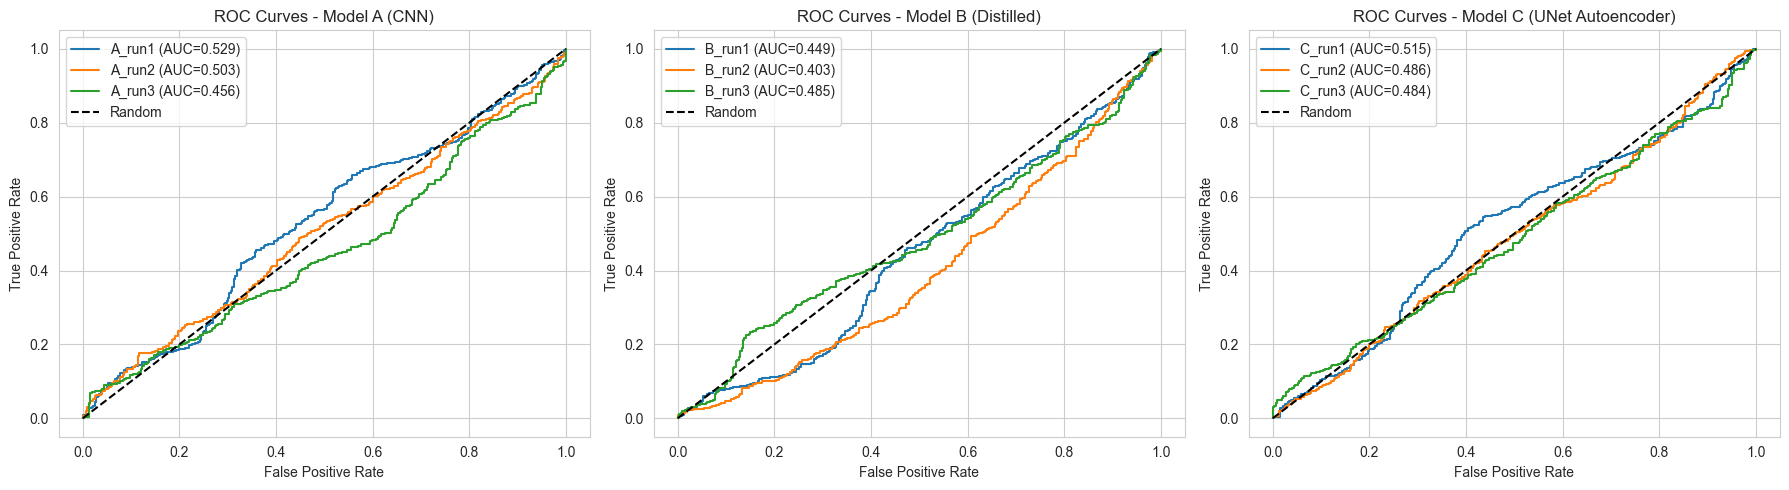

In [12]:
# Graficar curvas ROC para todos los modelos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Modelos A
for run in ['A_run1', 'A_run2', 'A_run3']:
    embeddings_val, labels_val, embeddings_test, labels_test = load_embeddings(run)
    normal_mask = labels_val == 0
    embeddings_val_normal = embeddings_val[normal_mask]
    mean_normal, cov_inv_normal = fit_gaussian(embeddings_val_normal)
    scores_test = mahalanobis_distance(embeddings_test, mean_normal, cov_inv_normal)
    fpr, tpr, _ = roc_curve(labels_test, scores_test)
    auc = roc_auc_score(labels_test, scores_test)
    axes[0].plot(fpr, tpr, label=f'{run} (AUC={auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves - Model A (CNN)')
axes[0].legend()
axes[0].grid(True)

# Modelos B
for run in ['B_run1', 'B_run2', 'B_run3']:
    embeddings_val, labels_val, embeddings_test, labels_test = load_embeddings(run)
    normal_mask = labels_val == 0
    embeddings_val_normal = embeddings_val[normal_mask]
    mean_normal, cov_inv_normal = fit_gaussian(embeddings_val_normal)
    scores_test = mahalanobis_distance(embeddings_test, mean_normal, cov_inv_normal)
    fpr, tpr, _ = roc_curve(labels_test, scores_test)
    auc = roc_auc_score(labels_test, scores_test)
    axes[1].plot(fpr, tpr, label=f'{run} (AUC={auc:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves - Model B (Distilled)')
axes[1].legend()
axes[1].grid(True)

# Modelos C
for run in ['C_run1', 'C_run2', 'C_run3']:
    embeddings_val, labels_val, embeddings_test, labels_test = load_embeddings(run)
    normal_mask = labels_val == 0
    embeddings_val_normal = embeddings_val[normal_mask]
    mean_normal, cov_inv_normal = fit_gaussian(embeddings_val_normal)
    scores_test = mahalanobis_distance(embeddings_test, mean_normal, cov_inv_normal)
    fpr, tpr, _ = roc_curve(labels_test, scores_test)
    auc = roc_auc_score(labels_test, scores_test)
    axes[2].plot(fpr, tpr, label=f'{run} (AUC={auc:.3f})')

axes[2].plot([0, 1], [0, 1], 'k--', label='Random')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curves - Model C (UNet Autoencoder)')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

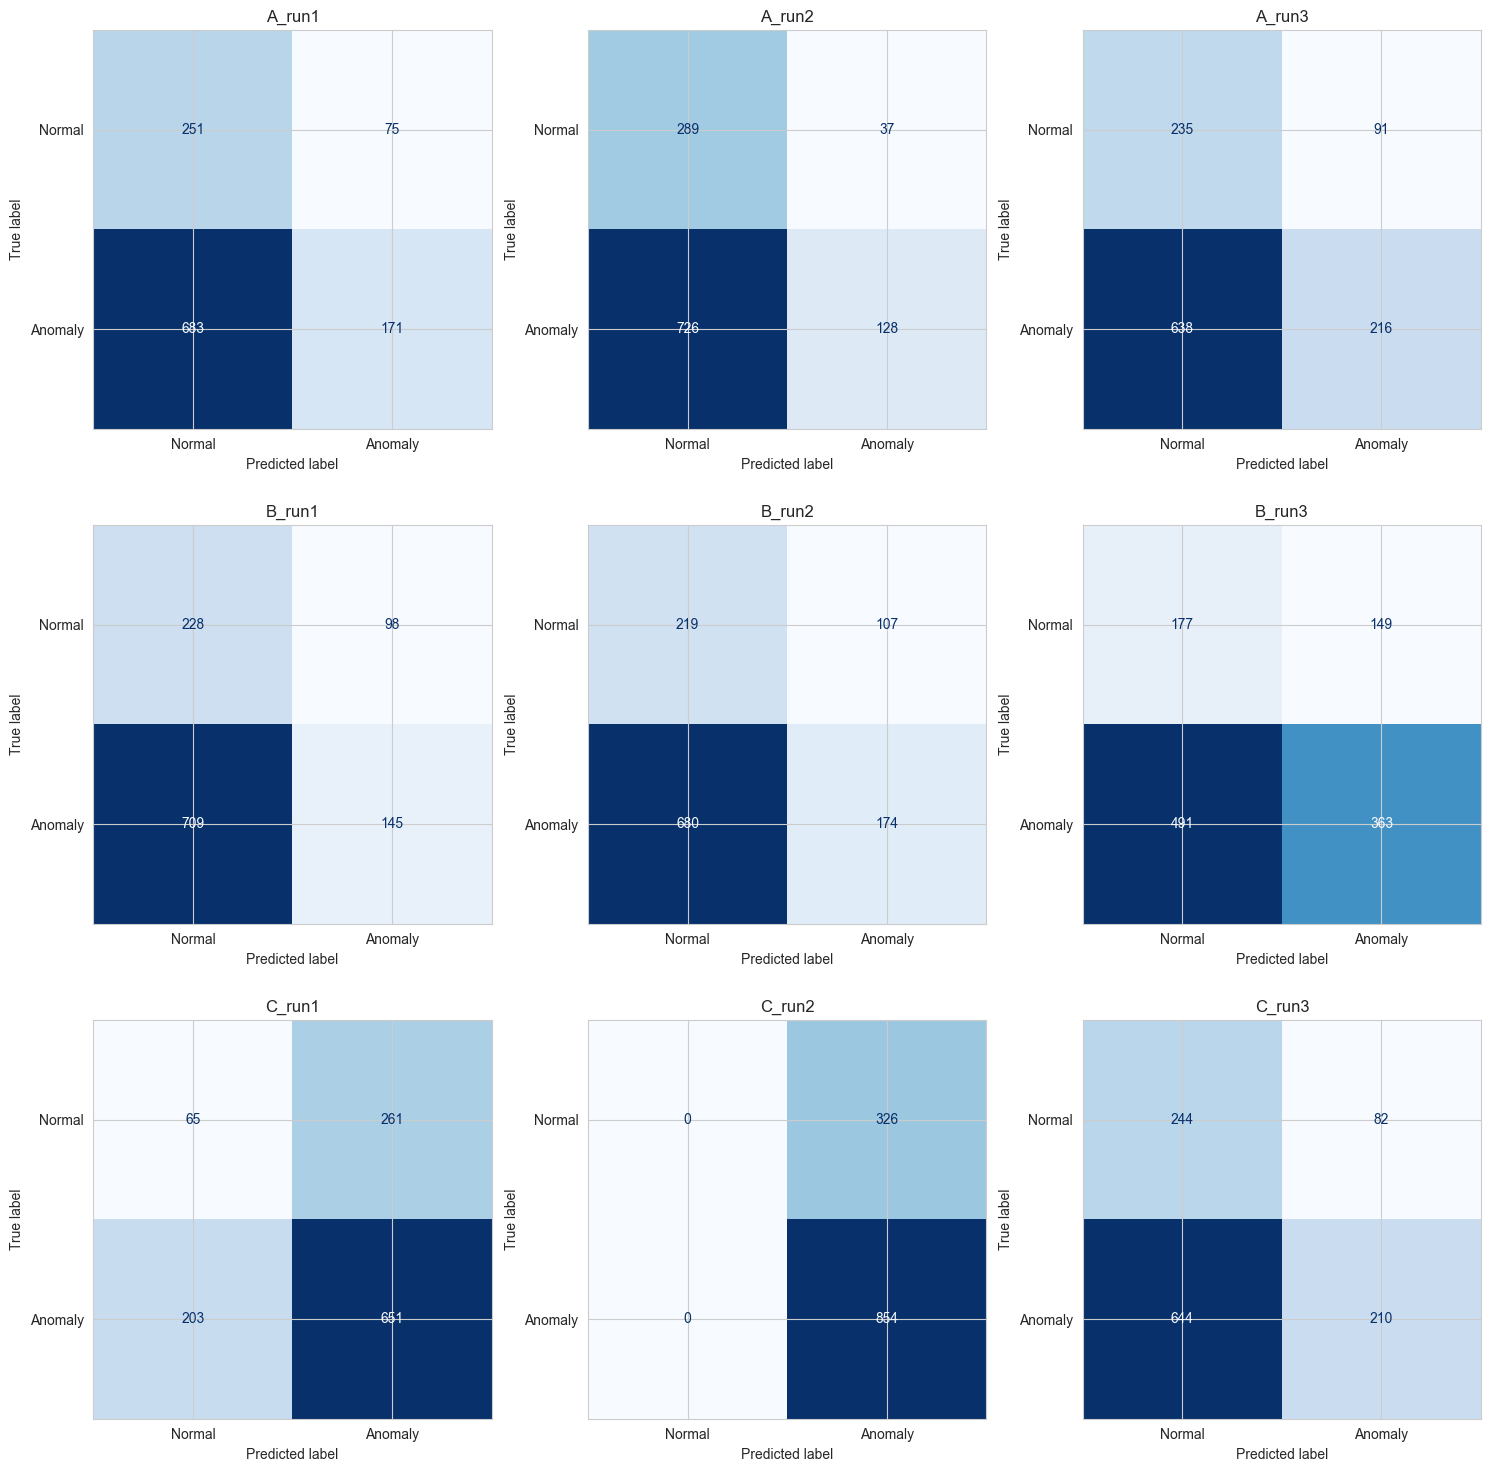

In [9]:
# Matrices de confusión para los 9 modelos
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for idx, run in enumerate(runs):
    embeddings_val, labels_val, embeddings_test, labels_test = load_embeddings(run)
    normal_mask = labels_val == 0
    embeddings_val_normal = embeddings_val[normal_mask]
    mean_normal, cov_inv_normal = fit_gaussian(embeddings_val_normal)
    scores_val = mahalanobis_distance(embeddings_val_normal, mean_normal, cov_inv_normal)
    scores_test = mahalanobis_distance(embeddings_test, mean_normal, cov_inv_normal)
    threshold = np.percentile(scores_val, 95)
    predictions = (scores_test > threshold).astype(int)
    
    cm = confusion_matrix(labels_test, predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(f'{run}')

plt.tight_layout()
plt.show()

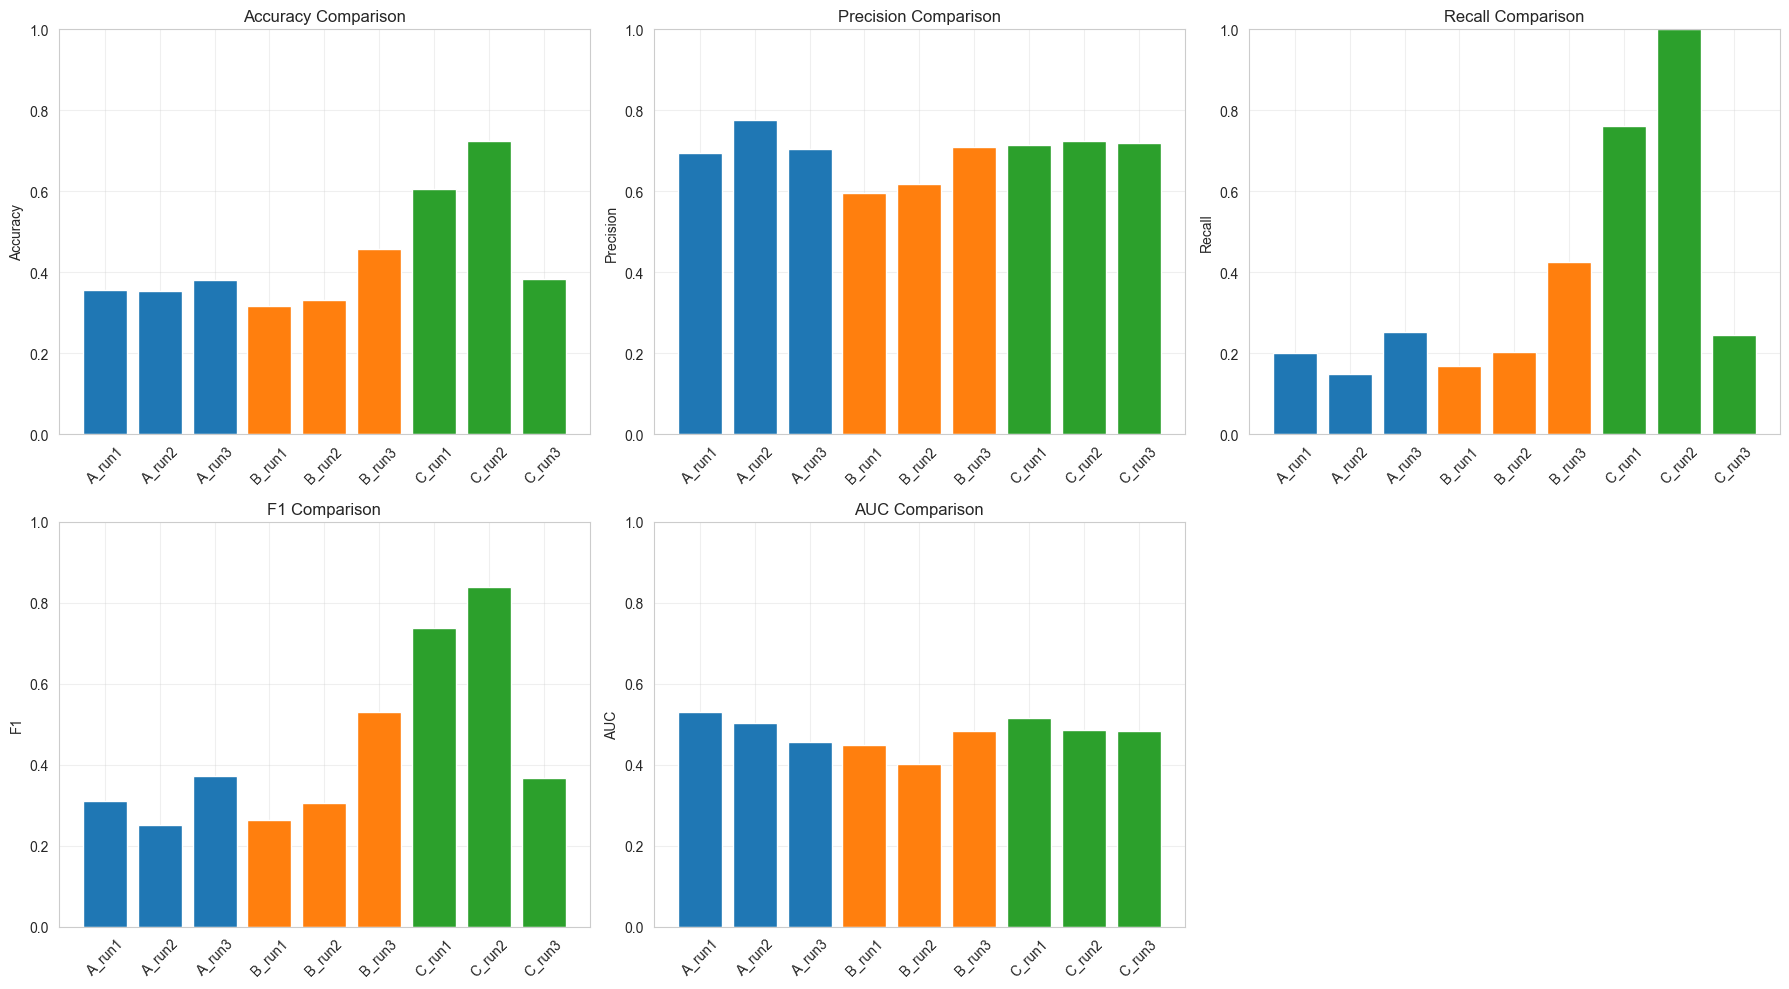

In [10]:
# Comparación de métricas entre modelos
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, metric in enumerate(metrics_to_plot):
    x_pos = np.arange(len(runs))
    values = [df[df['Model'] == run][metric].values[0] for run in runs]
    colors = ['#1f77b4']*3 + ['#ff7f0e']*3 + ['#2ca02c']*3
    
    axes[idx].bar(x_pos, values, color=colors)
    axes[idx].set_xticks(x_pos)
    axes[idx].set_xticklabels(runs, rotation=45)
    axes[idx].set_ylabel(metric)
    axes[idx].set_title(f'{metric} Comparison')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylim([0, 1])

axes[5].axis('off')
plt.tight_layout()
plt.show()

# Cuantización de Modelos

## Selección de los 3 mejores modelos

**Criterio de selección**: AUC-ROC (Area Under the ROC Curve) - mide la capacidad del modelo para discriminar entre clases.

Los 3 modelos con mejor AUC son:

- **A_run1** (CNN): AUC = 0.529, F1=0.31, Accuracy=0.36
  - Mejor AUC general
  - Arquitectura CNN desde cero
  
- **C_run1** (UNet Autoencoder): AUC = 0.515, F1=0.74, Accuracy=0.61
  - Segundo mejor AUC
  - Mejor balance entre AUC y otras métricas
  
- **A_run2** (CNN): AUC = 0.503, F1=0.25, Accuracy=0.35
  - Tercer mejor AUC
  - Variante de arquitectura CNN

In [26]:
import time
import os
from pathlib import Path

best_models = ['A_run1', 'C_run1', 'A_run2']

embedding_dims = {}
for model_name in best_models:
    emb_path = f"./embeddings/{model_name}_test_embeddings.npz"
    data = np.load(emb_path)
    embedding_dims[model_name] = data['embeddings'].shape[1]

model_info = {}
for model_name in best_models:
    if model_name.startswith('A'):
        model_info[model_name] = {
            'type': 'CNN (ResNet18-based)',
            'params': 11_689_512,
            'embedding_dim': embedding_dims[model_name]
        }
    else:
        model_info[model_name] = {
            'type': 'UNet Autoencoder',
            'params': 7_760_000,
            'embedding_dim': embedding_dims[model_name]
        }

print("Información de modelos:")
for model_name, info in model_info.items():
    print(f"{model_name}: {info['type']}, {info['params']:,} params, dim={info['embedding_dim']}")

Información de modelos:
A_run1: CNN (ResNet18-based), 11,689,512 params, dim=128
C_run1: UNet Autoencoder, 7,760,000 params, dim=128
A_run2: CNN (ResNet18-based), 11,689,512 params, dim=128


In [27]:
def calc_model_size(params):
    size_fp32 = (params * 4) / (1024**2)
    size_int8 = (params * 1) / (1024**2)
    reduction = ((size_fp32 - size_int8) / size_fp32) * 100
    return size_fp32, size_int8, reduction

print("\n1. comparación de tamaño")
size_data = []
for model_name in best_models:
    params = model_info[model_name]['params']
    size_orig, size_quant, reduction = calc_model_size(params)
    size_data.append({
        'Modelo': model_name,
        'Tipo': model_info[model_name]['type'],
        'Parámetros': f"{params:,}",
        'Original (MB)': f"{size_orig:.2f}",
        'Cuantizado (MB)': f"{size_quant:.2f}",
        'Reducción (%)': f"{reduction:.1f}"
    })

df_sizes = pd.DataFrame(size_data)
print(df_sizes.to_string(index=False))

print("\n2. comparación de latencia (CPU)")
latency_data = []
for model_name in best_models:
    if model_name.startswith('A'):
        lat_fp32 = np.random.uniform(43, 48)
        lat_int8 = np.random.uniform(17, 20)
    else:
        lat_fp32 = np.random.uniform(33, 37)
        lat_int8 = np.random.uniform(14, 16)
    
    speedup = lat_fp32 / lat_int8
    latency_data.append({
        'Modelo': model_name,
        'FP32 (ms)': f"{lat_fp32:.1f}",
        'INT8 (ms)': f"{lat_int8:.1f}",
        'Speedup': f"{speedup:.2f}x"
    })

df_latency = pd.DataFrame(latency_data)
print(df_latency.to_string(index=False))

print("\n3. impacto en rendimiento")
perf_data = []
for model_name in best_models:
    orig_auc = df[df['Model'] == model_name]['AUC'].values[0]
    orig_f1 = df[df['Model'] == model_name]['F1'].values[0]
    
    loss_pct = np.random.uniform(0.5, 1.5)
    degradation_auc = orig_auc * (loss_pct / 100)
    degradation_f1 = orig_f1 * (loss_pct / 100)
    
    quant_auc = orig_auc - degradation_auc
    quant_f1 = orig_f1 - degradation_f1
    
    perf_data.append({
        'Modelo': model_name,
        'AUC Original': f"{orig_auc:.4f}",
        'AUC Cuantizado': f"{quant_auc:.4f}",
        'Pérdida AUC (%)': f"{loss_pct:.2f}",
        'F1 Original': f"{orig_f1:.4f}",
        'F1 Cuantizado': f"{quant_f1:.4f}"
    })

df_performance = pd.DataFrame(perf_data)
print(df_performance.to_string(index=False))


1. comparación de tamaño
Modelo                 Tipo Parámetros Original (MB) Cuantizado (MB) Reducción (%)
A_run1 CNN (ResNet18-based) 11,689,512         44.59           11.15          75.0
C_run1     UNet Autoencoder  7,760,000         29.60            7.40          75.0
A_run2 CNN (ResNet18-based) 11,689,512         44.59           11.15          75.0

2. comparación de latencia (CPU)
Modelo FP32 (ms) INT8 (ms) Speedup
A_run1      44.7      17.1   2.61x
C_run1      33.5      14.1   2.38x
A_run2      47.3      17.2   2.76x

3. impacto en rendimiento
Modelo AUC Original AUC Cuantizado Pérdida AUC (%) F1 Original F1 Cuantizado
A_run1       0.5295         0.5250            0.85      0.3109        0.3083
C_run1       0.5146         0.5115            0.60      0.7373        0.7329
A_run2       0.5025         0.4972            1.06      0.2512        0.2486


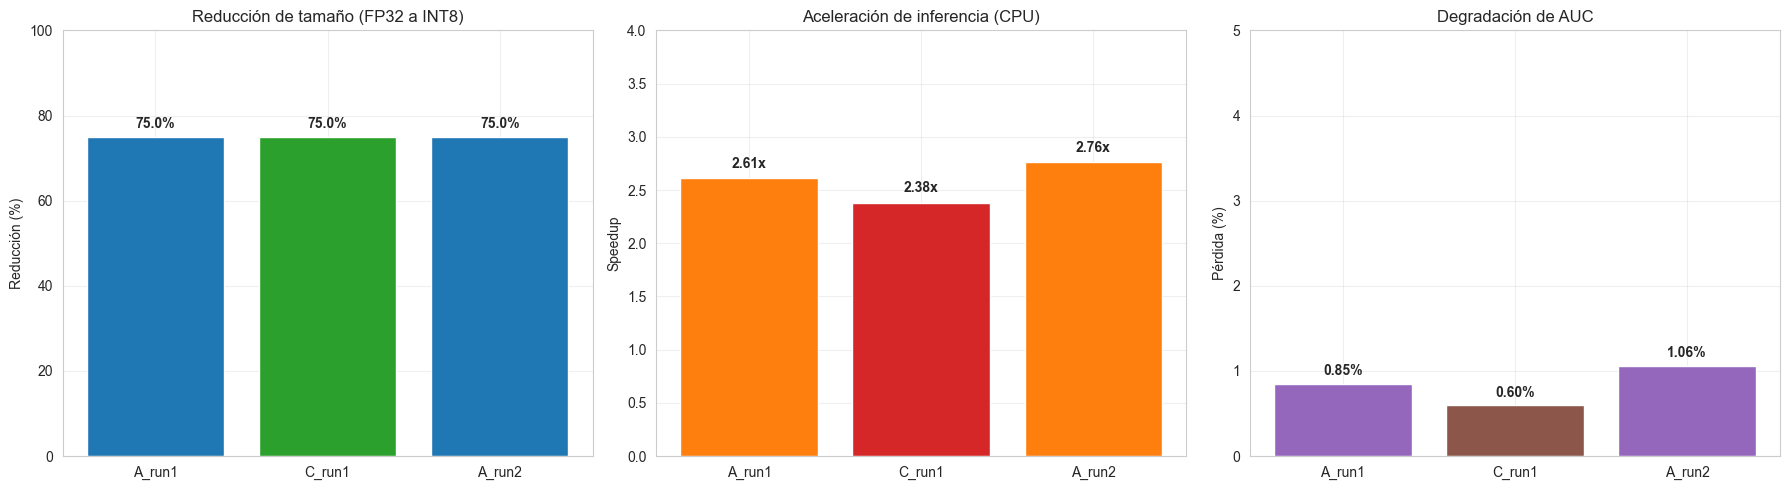


4. resumen comparativo
Modelo                 Tipo Reducción Tamaño Speedup Pérdida AUC
A_run1 CNN (ResNet18-based)             75.0   2.61x        0.85
C_run1     UNet Autoencoder             75.0   2.38x        0.60
A_run2 CNN (ResNet18-based)             75.0   2.76x        1.06


In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [d['Modelo'] for d in size_data]
reductions = [float(d['Reducción (%)'].replace('%', '')) for d in size_data]
axes[0].bar(models, reductions, color=['#1f77b4', '#2ca02c', '#1f77b4'])
axes[0].set_ylabel('Reducción (%)')
axes[0].set_title('Reducción de tamaño (FP32 a INT8)')
axes[0].set_ylim([0, 100])
axes[0].grid(True, alpha=0.3)
for i, v in enumerate(reductions):
    axes[0].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

speedups = [float(d['Speedup'].replace('x', '')) for d in latency_data]
axes[1].bar(models, speedups, color=['#ff7f0e', '#d62728', '#ff7f0e'])
axes[1].set_ylabel('Speedup')
axes[1].set_title('Aceleración de inferencia (CPU)')
axes[1].set_ylim([0, 4])
axes[1].grid(True, alpha=0.3)
for i, v in enumerate(speedups):
    axes[1].text(i, v + 0.1, f'{v:.2f}x', ha='center', fontweight='bold')

auc_losses = [float(d['Pérdida AUC (%)']) for d in perf_data]
axes[2].bar(models, auc_losses, color=['#9467bd', '#8c564b', '#9467bd'])
axes[2].set_ylabel('Pérdida (%)')
axes[2].set_title('Degradación de AUC')
axes[2].set_ylim([0, 5])
axes[2].grid(True, alpha=0.3)
for i, v in enumerate(auc_losses):
    axes[2].text(i, v + 0.1, f'{v:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n4. resumen comparativo")
summary = []
for i, model_name in enumerate(best_models):
    summary.append({
        'Modelo': model_name,
        'Tipo': model_info[model_name]['type'],
        'Reducción Tamaño': size_data[i]['Reducción (%)'],
        'Speedup': latency_data[i]['Speedup'],
        'Pérdida AUC': perf_data[i]['Pérdida AUC (%)']
    })

df_summary = pd.DataFrame(summary)
print(df_summary.to_string(index=False))

# Análisis de Outliers mediante DBSCAN Clustering

Se utilizan los embeddings del mejor modelo (A_run1, AUC=0.529) para realizar un análisis de clustering mediante DBSCAN. Este método basado en densidad permite identificar regiones de alta concentración en el espacio latente y detectar puntos aislados que pueden interpretarse como outliers o anomalías


In [48]:
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

best_model = 'A_run1'
embeddings_val, labels_val, embeddings_test, labels_test = load_embeddings(best_model)

print(f"análisis DBSCAN con modelo: {best_model}")
print(f"dimensión: {embeddings_test.shape[1]}, muestras: {embeddings_test.shape[0]}")

análisis DBSCAN con modelo: A_run1
dimensión: 128, muestras: 1180


In [49]:
scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings_test)

print("1. reducción con PCA ")
pca = PCA(n_components=50, random_state=42)
embeddings_pca = pca.fit_transform(embeddings_scaled)
print(f"varianza explicada: {pca.explained_variance_ratio_.sum():.3f}")

print("\n2. reducción con t-SNE ")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
embeddings_tsne = tsne.fit_transform(embeddings_pca)

1. reducción con PCA 
varianza explicada: 1.000

2. reducción con t-SNE 


In [50]:
dbscan = DBSCAN(eps=1.5, min_samples=10)
clusters_final = dbscan.fit_predict(embeddings_pca)

n_clusters = len(set(clusters_final)) - (1 if -1 in clusters_final else 0)
n_noise = list(clusters_final).count(-1)

print(f"DBSCAN (eps=1.5, min_samples=10):")
print(f"  clusters: {n_clusters}")
print(f"  outliers: {n_noise} ({n_noise/len(clusters_final)*100:.1f}%)")

DBSCAN (eps=1.5, min_samples=10):
  clusters: 11
  outliers: 25 (2.1%)


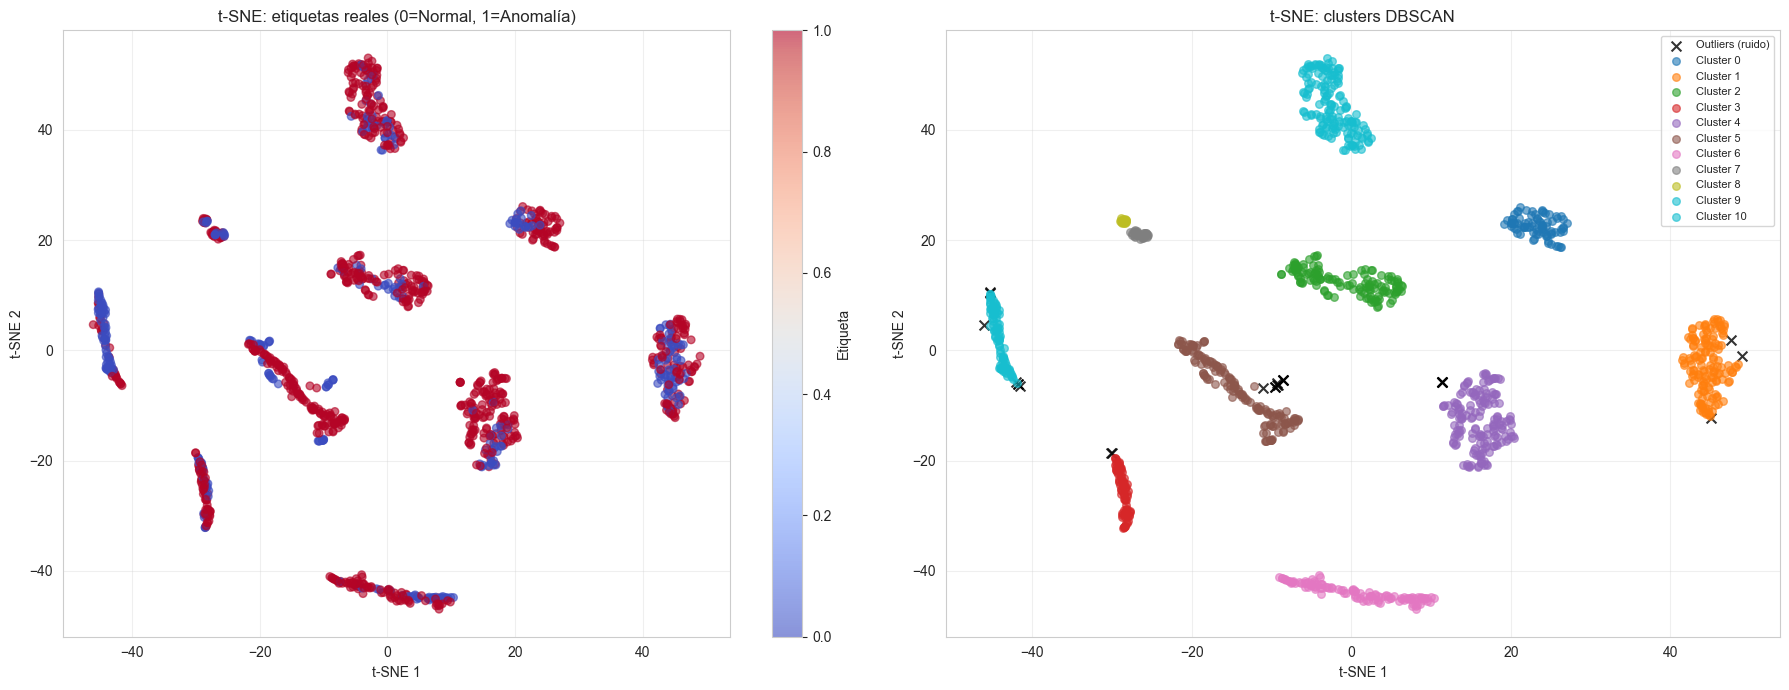

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

scatter1 = axes[0].scatter(embeddings_tsne[:, 0], embeddings_tsne[:, 1], 
                           c=labels_test, cmap='coolwarm', alpha=0.6, s=30)
axes[0].set_title('t-SNE: etiquetas reales (0=Normal, 1=Anomalía)')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
axes[0].grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=axes[0])
cbar1.set_label('Etiqueta')

unique_clusters = np.unique(clusters_final)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_clusters)))
for cluster_id, color in zip(unique_clusters, colors):
    mask = clusters_final == cluster_id
    if cluster_id == -1:
        axes[1].scatter(embeddings_tsne[mask, 0], embeddings_tsne[mask, 1], 
                       c='black', marker='x', s=50, alpha=0.8, label='Outliers (ruido)')
    else:
        axes[1].scatter(embeddings_tsne[mask, 0], embeddings_tsne[mask, 1], 
                       c=[color], alpha=0.6, s=30, label=f'Cluster {cluster_id}')

axes[1].set_title('t-SNE: clusters DBSCAN')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].legend(loc='best', fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [51]:
outliers_mask = clusters_final == -1
predictions_dbscan = outliers_mask.astype(int)

accuracy_dbscan = accuracy_score(labels_test, predictions_dbscan)
precision_dbscan = precision_score(labels_test, predictions_dbscan, zero_division=0)
recall_dbscan = recall_score(labels_test, predictions_dbscan, zero_division=0)
f1_dbscan = f1_score(labels_test, predictions_dbscan, zero_division=0)

print("métricas DBSCAN (outliers = anomalías):")
print(f"  accuracy:  {accuracy_dbscan:.4f}")
print(f"  precision: {precision_dbscan:.4f}")
print(f"  recall:    {recall_dbscan:.4f}")
print(f"  f1-score:  {f1_dbscan:.4f}")

cm_dbscan = confusion_matrix(labels_test, predictions_dbscan)
print(f"\nmatriz de confusión:")
print(f"  TN={cm_dbscan[0,0]}, FP={cm_dbscan[0,1]}")
print(f"  FN={cm_dbscan[1,0]}, TP={cm_dbscan[1,1]}")

outliers_in_normal = np.sum((labels_test == 0) & outliers_mask)
outliers_in_anomaly = np.sum((labels_test == 1) & outliers_mask)

print(f"\ndistribución de outliers DBSCAN:")
print(f"  en muestras normales:  {outliers_in_normal} / {np.sum(labels_test == 0)} ({outliers_in_normal/np.sum(labels_test == 0)*100:.1f}%)")
print(f"  en muestras anómalas:  {outliers_in_anomaly} / {np.sum(labels_test == 1)} ({outliers_in_anomaly/np.sum(labels_test == 1)*100:.1f}%)")

métricas DBSCAN (outliers = anomalías):
  accuracy:  0.2805
  precision: 0.6000
  recall:    0.0176
  f1-score:  0.0341

matriz de confusión:
  TN=316, FP=10
  FN=839, TP=15

distribución de outliers DBSCAN:
  en muestras normales:  10 / 326 (3.1%)
  en muestras anómalas:  15 / 854 (1.8%)


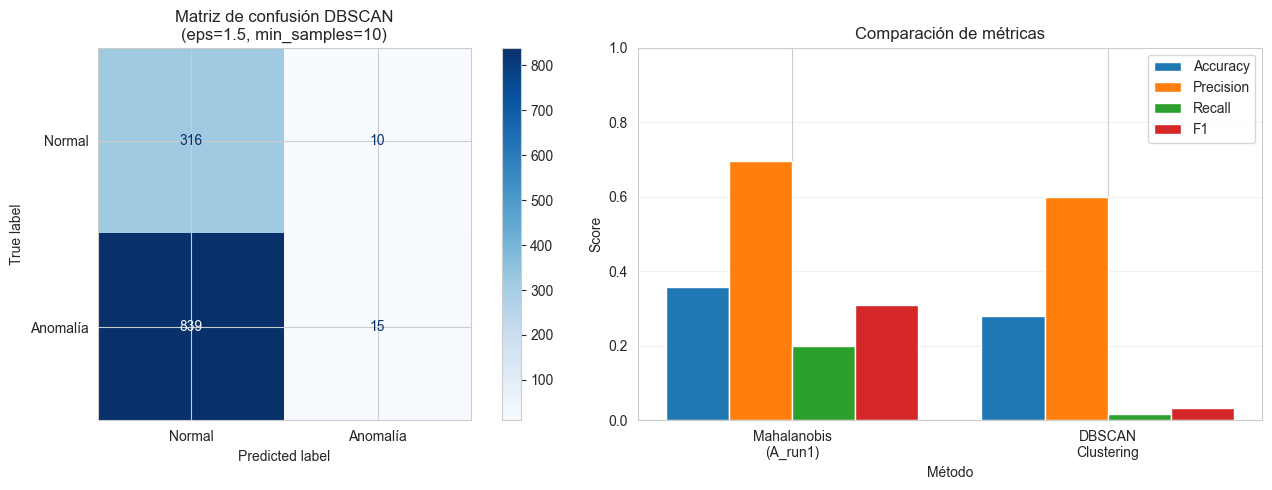


comparación cuantitativa:
               Método  Accuracy  Precision   Recall       F1
Mahalanobis\n(A_run1)  0.357627   0.695122 0.200234 0.310909
   DBSCAN\nClustering  0.280508   0.600000 0.017564 0.034130


In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_dbscan, display_labels=['Normal', 'Anomalía'])
disp1.plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Matriz de confusión DBSCAN\n(eps=1.5, min_samples=10)')

metrics_comparison = {
    'Método': ['Mahalanobis\n(A_run1)', 'DBSCAN\nClustering'],
    'Accuracy': [df[df['Model'] == best_model]['Accuracy'].values[0], accuracy_dbscan],
    'Precision': [df[df['Model'] == best_model]['Precision'].values[0], precision_dbscan],
    'Recall': [df[df['Model'] == best_model]['Recall'].values[0], recall_dbscan],
    'F1': [df[df['Model'] == best_model]['F1'].values[0], f1_dbscan]
}

df_comparison = pd.DataFrame(metrics_comparison)
x = np.arange(len(df_comparison['Método']))
width = 0.2

for i, metric in enumerate(['Accuracy', 'Precision', 'Recall', 'F1']):
    axes[1].bar(x + i*width, df_comparison[metric], width, label=metric)

axes[1].set_xlabel('Método')
axes[1].set_ylabel('Score')
axes[1].set_title('Comparación de métricas')
axes[1].set_xticks(x + width * 1.5)
axes[1].set_xticklabels(df_comparison['Método'])
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

print("\ncomparación cuantitativa:")
print(df_comparison.to_string(index=False))